In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

In [ ]:
dates = pd.date_range(start="2023-01-01", periods=365)

data = pd.DataFrame({
    "date": dates,
    "sales": np.random.poisson(20, size=365)
})

# Add seasonality
data["sales"] = data["sales"] + 10*np.sin(np.arange(365)/30)

# Add random spikes
data.loc[np.random.choice(data.index, 20), "sales"] += 30

data.to_csv("retail_data.csv", index=False)

data.head()

,date,sales
0,2023-01-01,19.000000
1,2023-01-02,15.333272
2,2023-01-03,18.666173
3,2023-01-04,20.998334
4,2023-01-05,30.329386


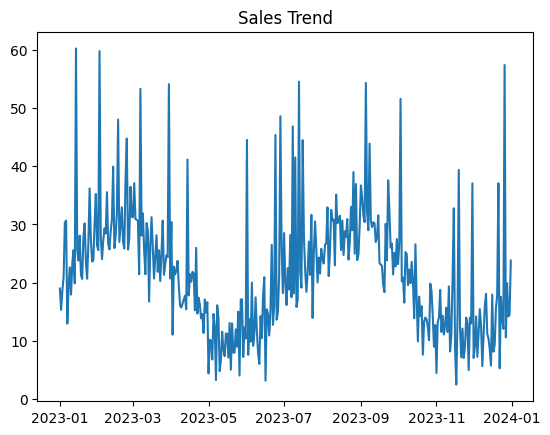

In [ ]:
plt.figure()
plt.plot(data['date'], data['sales'])
plt.title("Sales Trend")
plt.show()

In [ ]:
df = data.copy()

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek

df['lag_1'] = df['sales'].shift(1)
df['lag_7'] = df['sales'].shift(7)

df = df.dropna()

df.head()

,date,sales,day,month,dayofweek,lag_1,lag_7
7,2023-01-08,19.312218,8,1,6,12.986693,19.000000
8,2023-01-09,22.635174,9,1,0,19.312218,15.333272
9,2023-01-10,17.955202,10,1,1,22.635174,18.666173
10,2023-01-11,23.271947,11,1,2,17.955202,20.998334
11,2023-01-12,25.585057,12,1,3,23.271947,30.329386


In [ ]:
features = ['day','month','dayofweek','lag_1','lag_7']

X = df[features]
y = df['sales']

model = RandomForestRegressor(n_estimators=100)
model.fit(X, y)

pred = model.predict(X)

print("MAE:", mean_absolute_error(y, pred))

MAE: 2.255063568308277


In [ ]:
joblib.dump(model, "forecast_model.pkl")

['forecast_model.pkl']

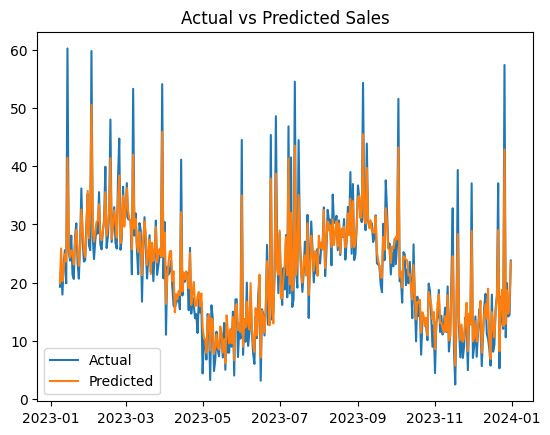

In [ ]:
plt.figure()
plt.plot(df['date'], y, label="Actual")
plt.plot(df['date'], pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [ ]:
df['prediction'] = pred

lead_time = 7
z = 1.65

demand_std = np.std(pred)

df['safety_stock'] = z * demand_std * np.sqrt(lead_time)

df['reorder_point'] = df['prediction'] * lead_time + df['safety_stock']

df['order_quantity'] = df['reorder_point'] - df['prediction']

df[['date','prediction','safety_stock','reorder_point','order_quantity']].head()

,date,prediction,safety_stock,reorder_point,order_quantity
7,2023-01-08,19.915358,36.901577,176.309083,156.393725
8,2023-01-09,25.869050,36.901577,217.984925,192.115875
9,2023-01-10,20.252771,36.901577,178.670977,158.418205
10,2023-01-11,22.360606,36.901577,193.425821,171.065215
11,2023-01-12,24.919769,36.901577,211.339961,186.420192


In [ ]:
df.to_csv("final_inventory_output.csv", index=False)

In [ ]:
from google.colab import files

files.download("retail_data.csv")
files.download("final_inventory_output.csv")
files.download("forecast_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>